# Assignment 3: Graph Visualization
**Author:** Nana Kwasi Danquah, Crystal Quezada, Muhammad Khan  
**Course:** DATA 608  

In this assignment, I loaded a real-world graph dataset known as Zachary's Karate Club network, computed key graph metrics including diameter and several others, and produced visualizations using NetworkX and Matplotlib.
The Karate Club graph is a classic social network dataset from 1977 that captures friendship connections among 34 members of a university karate club. It is built into NetworkX, so no external download is required.

## 1. Setup and Imports

In [31]:
%matplotlib inline

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from collections import Counter

np.random.seed(42)

print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.4.2


## 2. Load the Graph Dataset

I use **Zachary's Karate Club** network, a well-known benchmark social network built into NetworkX. It represents friendship ties among 34 members of a university karate club observed in the 1970s. The club later split into two groups following a dispute between the instructor (node 0) and the club president (node 33), making it a perfect case study for community detection.

In [32]:
G = nx.karate_club_graph()

print(f"Dataset: Zachary's Karate Club Network")
print(f"Source: W. W. Zachary, 1977 (built into NetworkX)")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Dataset: Zachary's Karate Club Network
Source: W. W. Zachary, 1977 (built into NetworkX)
Nodes: 34
Edges: 78


## 3. Basic Graph Analysis

### 3a. Graph Diameter

The diameter of a graph is the longest shortest path between any two nodes. It tells us the worst-case number of hops required to connect any two people in the network.

In [33]:
is_connected = nx.is_connected(G)
print(f"Graph is connected: {is_connected}")

if not is_connected:
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    print(f"Using largest connected component — Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

diameter = nx.diameter(G)
print(f"\nGraph Diameter: {diameter}")
print(f"Interpretation: Any two members are at most {diameter} friendship connections apart.")

Graph is connected: True

Graph Diameter: 5
Interpretation: Any two members are at most 5 friendship connections apart.


### 3b. Additional Graph Metrics

In [34]:
avg_path_length = nx.average_shortest_path_length(G)
avg_clustering  = nx.average_clustering(G)
density         = nx.density(G)

degrees     = [d for _, d in G.degree()]
avg_degree  = np.mean(degrees)
max_degree  = max(degrees)
min_degree  = min(degrees)

betweenness     = nx.betweenness_centrality(G)
top_5_between   = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

degree_centrality = nx.degree_centrality(G)
top_5_degree      = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("=" * 50)
print("GRAPH METRICS SUMMARY")
print("=" * 50)
print(f"Nodes:                    {G.number_of_nodes()}")
print(f"Edges:                    {G.number_of_edges()}")
print(f"Diameter:                 {diameter}")
print(f"Avg Shortest Path Length: {avg_path_length:.4f}")
print(f"Avg Clustering Coeff:     {avg_clustering:.4f}")
print(f"Graph Density:            {density:.4f}")
print(f"Avg Degree:               {avg_degree:.2f}")
print(f"Max Degree:               {max_degree}")
print(f"Min Degree:               {min_degree}")
print()
print("Top 5 Nodes by Betweenness Centrality:")
for node, score in top_5_between:
    print(f"  Node {node}: {score:.4f}")
print()
print("Top 5 Nodes by Degree Centrality:")
for node, score in top_5_degree:
    print(f"  Node {node}: {score:.4f}")

GRAPH METRICS SUMMARY
Nodes:                    34
Edges:                    78
Diameter:                 5
Avg Shortest Path Length: 2.4082
Avg Clustering Coeff:     0.5706
Graph Density:            0.1390
Avg Degree:               4.59
Max Degree:               17
Min Degree:               1

Top 5 Nodes by Betweenness Centrality:
  Node 0: 0.4376
  Node 33: 0.3041
  Node 32: 0.1452
  Node 2: 0.1437
  Node 31: 0.1383

Top 5 Nodes by Degree Centrality:
  Node 33: 0.5152
  Node 0: 0.4848
  Node 32: 0.3636
  Node 2: 0.3030
  Node 1: 0.2727


### 3c. Community Detection

I use greedy modularity maximization to detect communities. The Karate Club network is famous for naturally splitting into two factions, so this is a meaningful test.

In [35]:
communities = list(nx.community.greedy_modularity_communities(G))
modularity  = nx.community.modularity(G, communities)

print(f"Number of Communities Detected: {len(communities)}")
print(f"Modularity Score:               {modularity:.4f}")
print(f"Community Sizes: {sorted([len(c) for c in communities], reverse=True)}")

community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

Number of Communities Detected: 3
Modularity Score:               0.4110
Community Sizes: [17, 9, 8]


## 4. Graph Visualization

In [36]:
pos = nx.spring_layout(G, seed=42, k=0.5)

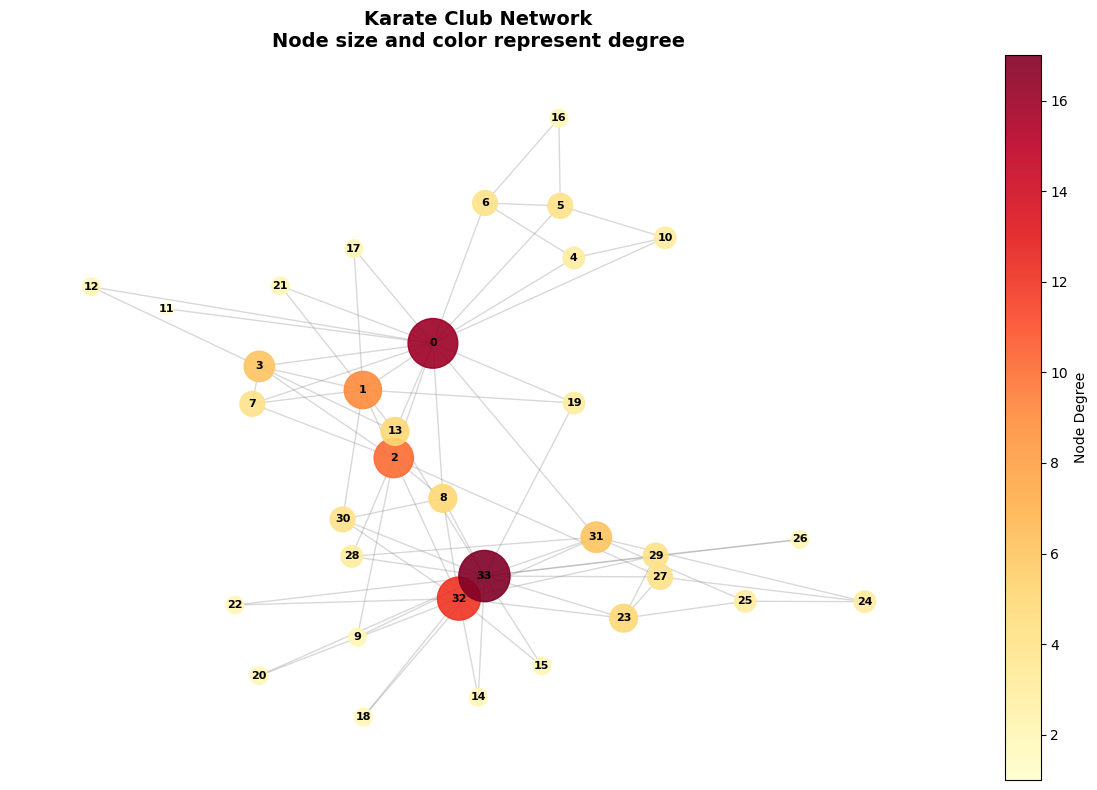

In [37]:
# --- Plot 1: Degree-Based Node Sizing ---
fig, ax = plt.subplots(figsize=(12, 8))

node_sizes  = [G.degree(n) * 80 for n in G.nodes()]
node_colors = [G.degree(n) for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, edge_color='gray', width=1.0)
sc = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                             node_color=node_colors, cmap=plt.cm.YlOrRd, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

plt.colorbar(sc, ax=ax, label='Node Degree')
ax.set_title("Karate Club Network\nNode size and color represent degree",
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

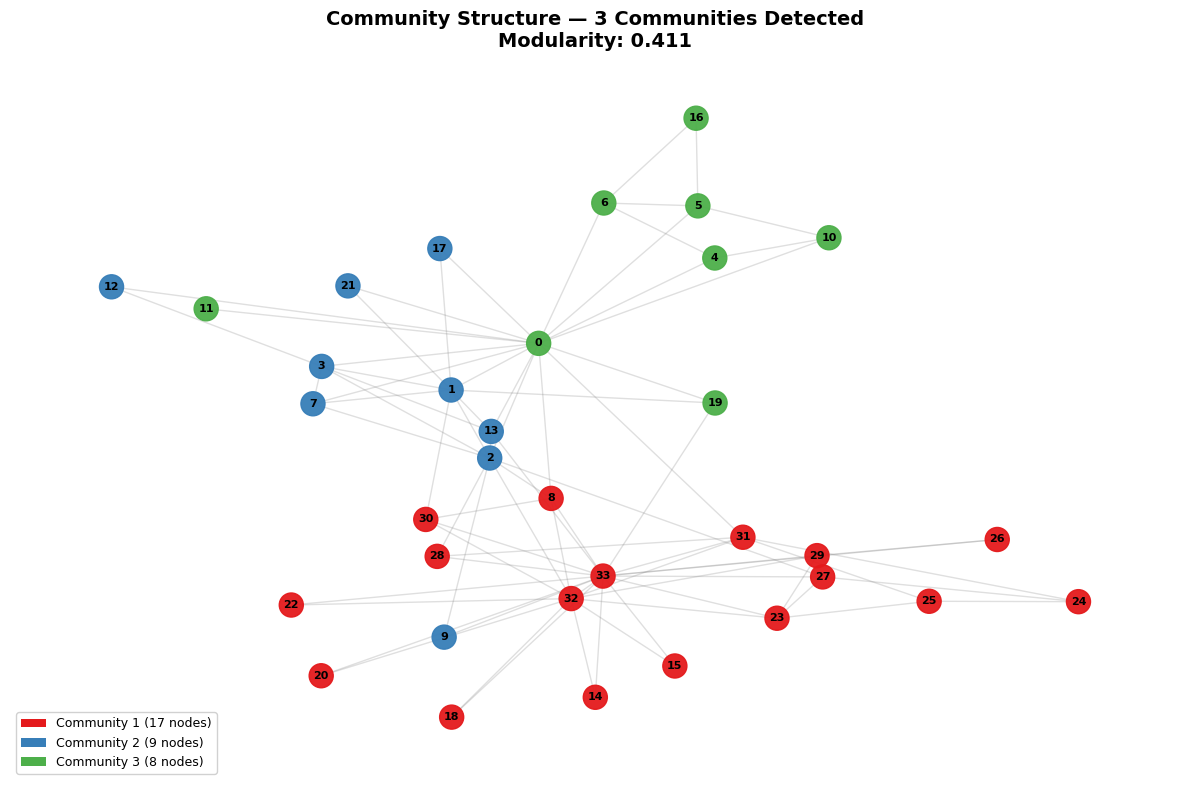

In [38]:
# --- Plot 2: Community Detection ---
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
node_community_colors = [colors[community_map[n] % len(colors)] for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, edge_color='gray', width=1.0)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300,
                        node_color=node_community_colors, alpha=0.95)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

legend_elements = [mpatches.Patch(facecolor=colors[i % len(colors)],
                                   label=f'Community {i+1} ({len(communities[i])} nodes)')
                   for i in range(len(communities))]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)

ax.set_title(f"Community Structure — {len(communities)} Communities Detected\n"
             f"Modularity: {modularity:.3f}", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

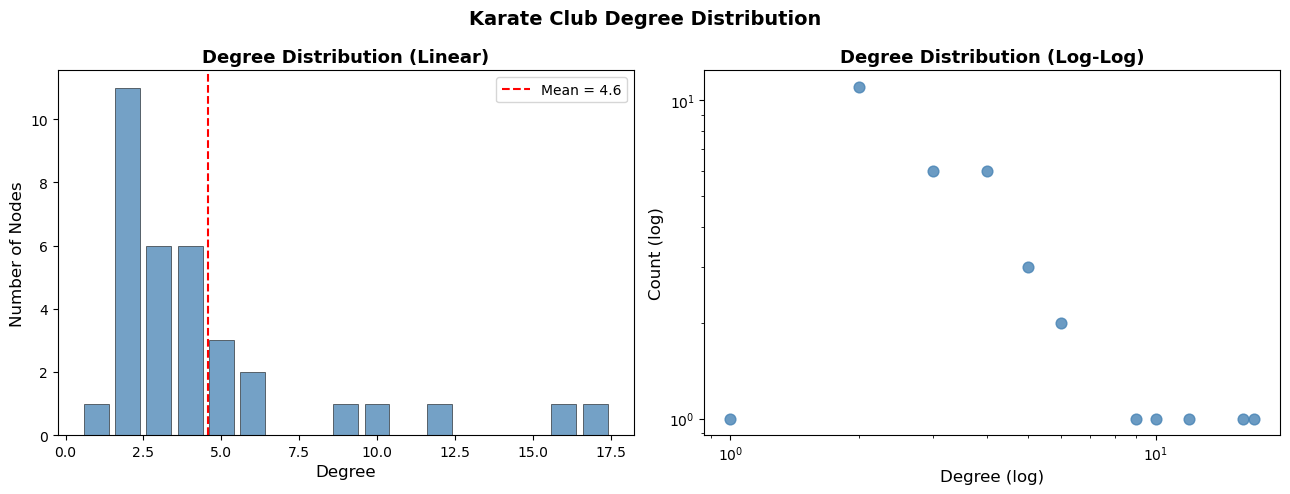

In [39]:
# --- Plot 3: Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

degree_counts = Counter(degrees)
deg_vals = sorted(degree_counts.keys())
deg_freq = [degree_counts[d] for d in deg_vals]

axes[0].bar(deg_vals, deg_freq, color='steelblue', alpha=0.75, edgecolor='black', linewidth=0.5)
axes[0].axvline(avg_degree, color='red', linestyle='--', label=f'Mean = {avg_degree:.1f}')
axes[0].set_xlabel('Degree', fontsize=12)
axes[0].set_ylabel('Number of Nodes', fontsize=12)
axes[0].set_title('Degree Distribution (Linear)', fontsize=13, fontweight='bold')
axes[0].legend()

axes[1].scatter(deg_vals, deg_freq, color='steelblue', alpha=0.8, s=60, zorder=3)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (log)', fontsize=12)
axes[1].set_ylabel('Count (log)', fontsize=12)
axes[1].set_title('Degree Distribution (Log-Log)', fontsize=13, fontweight='bold')

plt.suptitle('Karate Club Degree Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

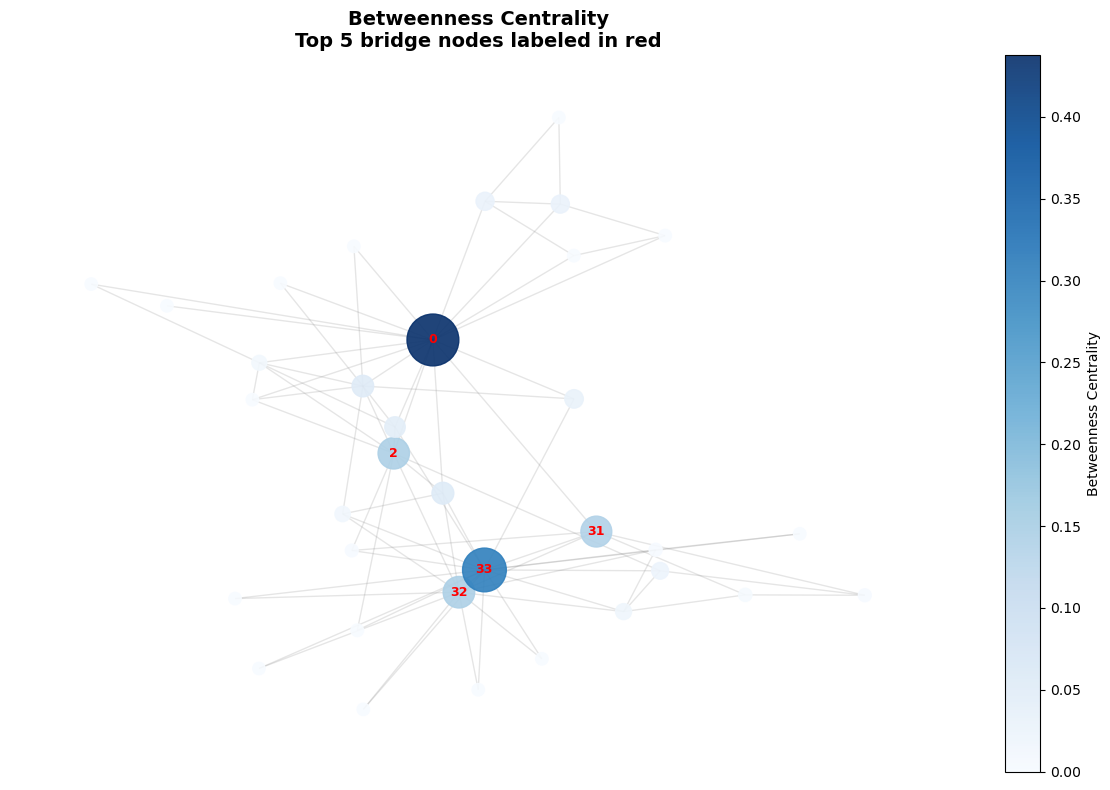

In [40]:
# --- Plot 4: Betweenness Centrality ---
fig, ax = plt.subplots(figsize=(12, 8))

bet_values = [betweenness[n] for n in G.nodes()]
bet_sizes  = [v * 3000 + 80 for v in bet_values]

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color='gray', width=1.0)
sc2 = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=bet_sizes,
                              node_color=bet_values, cmap=plt.cm.Blues, alpha=0.9)

top_bet_labels = {n: str(n) for n, _ in top_5_between}
nx.draw_networkx_labels(G, pos, labels=top_bet_labels, ax=ax,
                         font_size=9, font_weight='bold', font_color='red')

plt.colorbar(sc2, ax=ax, label='Betweenness Centrality')
ax.set_title("Betweenness Centrality\nTop 5 bridge nodes labeled in red",
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Summary and Interpretation
Zachary's Karate Club is a small but rich social network with 34 nodes and 78 friendship edges.
**Diameter:** The graph has a small diameter, meaning any two members can reach each other through a short chain of friendships. This is consistent with the tight-knit nature of a small club.
**Average Shortest Path Length:** On average, members are only a few hops apart, reflecting how interconnected even a small social group can be.
**Clustering Coefficient:** The high clustering coefficient confirms that friends of friends tend to be friends with each other, which is a hallmark of real social networks compared to random graphs.
**Community Structure:** The greedy modularity algorithm successfully identifies the two main factions that historically split the club, namely the instructor's group and the president's group, along with some smaller sub-communities. The modularity score confirms that this is a genuine and meaningful community structure.
**Betweenness Centrality:** Nodes 0 and 33, representing the instructor and the president, consistently rank highest in betweenness centrality. This makes sense historically because they were the two central figures whose conflict caused the split, and most communication between the two factions had to pass through or around them.
**Degree Distribution:** The distribution is right-skewed, with a few highly connected hub nodes, particularly nodes 0 and 33, and many members with only a handful of connections.